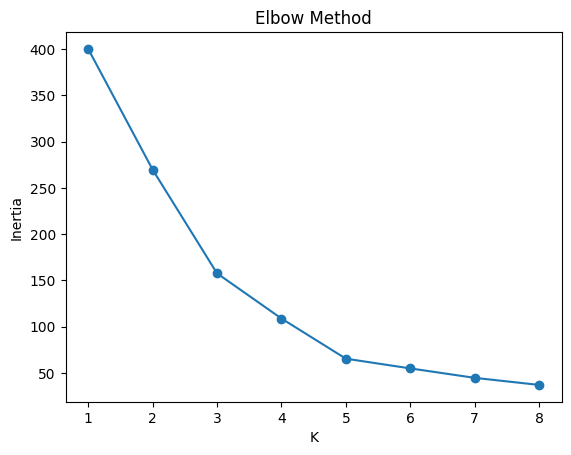

In [1]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Dataset/Mall_Customers.csv')
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Chuẩn hóa dữ liệu trước khi tính khoảng cách (lý do: 2️⃣)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
for k in range(1, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,9), inertia, marker='o')
plt.xlabel('K'); plt.ylabel('Inertia'); plt.title('Elbow Method')
plt.show()

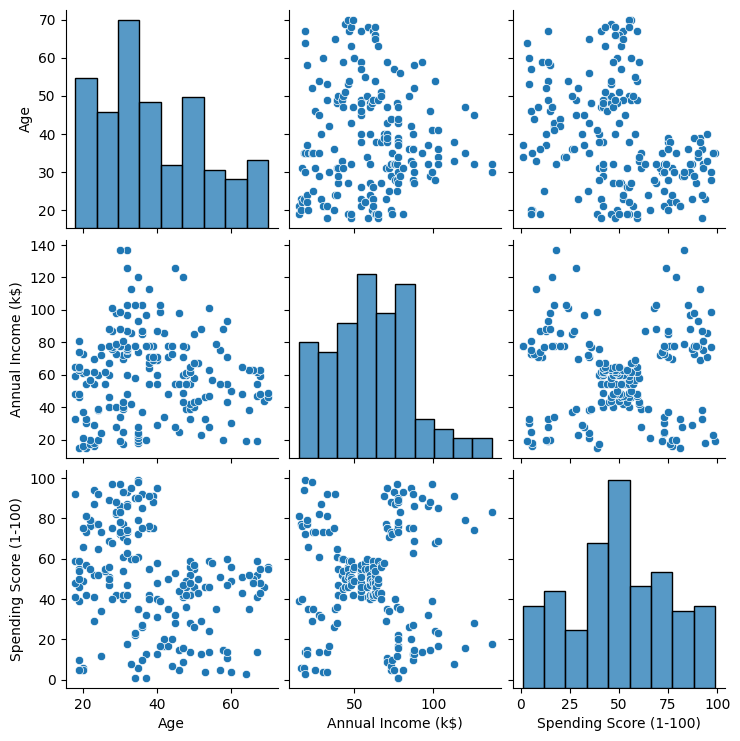

In [3]:
sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])
plt.show()

In [2]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
X

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


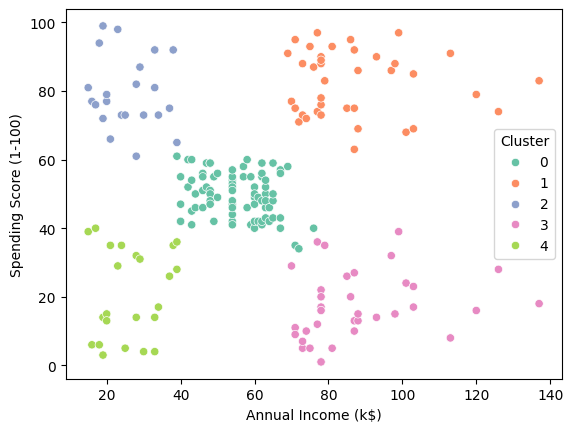

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


In [7]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', palette='Set2')
plt.show()

print(df.groupby('Cluster')[['Annual Income (k$)','Spending Score (1-100)']].mean())

In [8]:
# Kịch bản 1: Giảm còn K=3 → mất nhóm VIP riêng biệt?
km3 = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_scaled)
print(X.groupby(km3.labels_).mean())

# Kịch bản 2: Khách hàng mới thuộc nhóm nào?
# Dùng scaler.transform() (KHÔNG fit lại) vì phải áp dụng đúng thước đo cũ (lý do: 4️⃣)
new_cust = pd.DataFrame([[85, 90]], columns=X.columns)
new_cust_scaled = scaler.transform(new_cust)
print("Khách mới (Income 85k, Spending 90) → cụm:", kmeans.predict(new_cust_scaled)[0])

# Kịch bản 3: Thêm biến Age có đổi kết quả phân khúc không?
X_age = df[['Age','Annual Income (k$)','Spending Score (1-100)']]
X_age_scaled = StandardScaler().fit_transform(X_age)
km_age = KMeans(n_clusters=5, random_state=42, n_init=10).fit(X_age_scaled)
df['Cluster_age'] = km_age.labels_
print(df.groupby('Cluster_age')[['Age','Annual Income (k$)','Spending Score (1-100)']].mean())

   Annual Income (k$)  Spending Score (1-100)
0           87.000000               18.631579
1           86.538462               82.128205
2           44.154472               49.829268
Khách mới (Income 85k, Spending 90) → cụm: 1
                   Age  Annual Income (k$)  Spending Score (1-100)
Cluster_age                                                       
0            46.250000           26.750000               18.350000
1            25.185185           41.092593               62.240741
2            32.875000           86.100000               81.525000
3            39.871795           86.102564               19.358974
4            55.638298           54.382979               48.851064


In [4]:
from sklearn.cluster import KMeans

# Chạy nhiều lần với n_init=1 → kết quả có thể khác nhau mỗi lần chạy
for seed in [0, 1, 2]:
    km = KMeans(n_clusters=5, n_init=1, random_state=seed).fit(X_scaled)
    print(f"Seed {seed} - n_init=1  → Inertia: {round(km.inertia_, 2)}")

print("---")

# Chạy với n_init=10 → kết quả ổn định hơn nhiều, inertia luôn ở mức tốt nhất có thể
for seed in [0, 1, 2]:
    km = KMeans(n_clusters=5, n_init=10, random_state=seed).fit(X_scaled)
    print(f"Seed {seed} - n_init=10 → Inertia: {round(km.inertia_, 2)}")

Seed 0 - n_init=1  → Inertia: 65.57
Seed 1 - n_init=1  → Inertia: 65.58
Seed 2 - n_init=1  → Inertia: 65.57
---
Seed 0 - n_init=10 → Inertia: 65.57
Seed 1 - n_init=10 → Inertia: 65.57
Seed 2 - n_init=10 → Inertia: 65.57
